# EfficientNetV2-S Waste Classifier (384px)

This notebook trains an ImageNet-pretrained EfficientNetV2-S model on `dataset/standardized_384` for 10 waste categories.

It logs loss/accuracy plus validation recall and F1 score, saves the best checkpoint, plots training vs validation curves, and evaluates the best model with a confusion matrix on the test split.


In [1]:
import os
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from PIL import Image

from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)

@dataclass
class Config:
    data_dir: str = "dataset/standardized_384"
    img_size: int = 384
    # Reduced batch size to avoid CUDA OOM on smaller-memory GPUs.
    batch_size: int = 16
    # Use 0 workers to avoid multiprocessing BrokenPipe issues in notebooks.
    num_workers: int = 0
    epochs: int = 20
    lr: float = 3e-4
    weight_decay: float = 1e-4
    val_ratio: float = 0.10
    test_ratio: float = 0.10

cfg = Config()
print(cfg)


Device: cuda
Torch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
Config(data_dir='dataset/standardized_384', img_size=384, batch_size=16, num_workers=0, epochs=20, lr=0.0003, weight_decay=0.0001, val_ratio=0.1, test_ratio=0.1)


/home/peter/Documents/IndividualProject5.0/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
class WasteDataset(Dataset):
    """Dataset wrapper that applies transforms to (path, label) samples."""

    def __init__(self, samples, transform=None):
        self.samples = samples  # list of (image_path, label)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label


# Load all samples + class labels from ImageFolder
base_dataset = datasets.ImageFolder(cfg.data_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

samples = base_dataset.samples  # (path, class_idx)
targets = np.array([label for _, label in samples], dtype=np.int64)

rng = np.random.default_rng(SEED)
train_samples, val_samples, test_samples = [], [], []

# Stratified split: 80% train / 10% val / 10% test per class
for class_idx in range(num_classes):
    class_indices = np.where(targets == class_idx)[0]
    rng.shuffle(class_indices)

    n_total = len(class_indices)
    n_train = int((1.0 - cfg.val_ratio - cfg.test_ratio) * n_total)
    n_val = int(cfg.val_ratio * n_total)
    n_test = n_total - n_train - n_val

    train_idx = class_indices[:n_train]
    val_idx = class_indices[n_train : n_train + n_val]
    test_idx = class_indices[n_train + n_val : n_train + n_val + n_test]

    train_samples.extend([samples[i] for i in train_idx])
    val_samples.extend([samples[i] for i in val_idx])
    test_samples.extend([samples[i] for i in test_idx])

print("Dataset sizes:")
print("  train:", len(train_samples))
print("  val:  ", len(val_samples))
print("  test: ", len(test_samples))


# EfficientNetV2-S normalization values
# (Using ImageNet mean/std; EfficientNetV2 weights expect ImageNet-preprocessed inputs.)
from torchvision.models import EfficientNet_V2_S_Weights

weights = EfficientNet_V2_S_Weights.DEFAULT
# ImageNet normalization.
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.Resize((cfg.img_size, cfg.img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((cfg.img_size, cfg.img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
)

train_ds = WasteDataset(train_samples, transform=train_transform)
val_ds = WasteDataset(val_samples, transform=eval_transform)
test_ds = WasteDataset(test_samples, transform=eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    persistent_workers=(cfg.num_workers > 0),
    pin_memory=(device.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    persistent_workers=(cfg.num_workers > 0),
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    persistent_workers=(cfg.num_workers > 0),
    pin_memory=(device.type == "cuda"),
)

print("DataLoaders ready.")


Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Num classes: 10
Dataset sizes:
  train: 9802
  val:   1221
  test:  1236
DataLoaders ready.


In [3]:
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

# ImageNet-pretrained EfficientNetV2-S
weights = EfficientNet_V2_S_Weights.DEFAULT
model = efficientnet_v2_s(weights=weights)

# Replace classifier head to match our 10 waste categories
if isinstance(model.classifier, nn.Sequential) and isinstance(model.classifier[-1], nn.Linear):
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
else:
    raise RuntimeError("Unexpected EfficientNetV2-S classifier structure")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

print(model)
print("Classifier out_features:", model.classifier[-1].out_features)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [ ]:
def confusion_metrics_from_cm(cm: np.ndarray):
    """Compute accuracy + weighted recall/F1 from a confusion matrix.

    cm shape: [num_classes, num_classes] where rows=true and cols=pred.
    """
    cm = cm.astype(np.int64)
    num_classes_local = cm.shape[0]

    total = cm.sum()
    correct = np.trace(cm)
    acc = float(correct / total) if total > 0 else 0.0

    support = cm.sum(axis=1)  # true count per class
    tp = np.diag(cm)
    pred_sum = cm.sum(axis=0)

    # per-class recall/precision
    recall = np.divide(tp, support, out=np.zeros(num_classes_local, dtype=np.float64), where=support != 0)
    precision = np.divide(tp, pred_sum, out=np.zeros(num_classes_local, dtype=np.float64), where=pred_sum != 0)

    # per-class F1
    denom = precision + recall
    f1 = np.divide(
        2 * precision * recall,
        denom,
        out=np.zeros(num_classes_local, dtype=np.float64),
        where=denom != 0,
    )

    # Weighted by support
    support_sum = support.sum()
    weighted_recall = float((recall * support).sum() / support_sum) if support_sum > 0 else 0.0
    weighted_f1 = float((f1 * support).sum() / support_sum) if support_sum > 0 else 0.0

    return acc, weighted_recall, weighted_f1


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    cm = np.zeros((num_classes, num_classes), dtype=np.int64)

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += float(loss.item())
            total_batches += 1

            preds = outputs.argmax(dim=1)
            preds_cpu = preds.detach().cpu().numpy()
            labels_cpu = labels.detach().cpu().numpy()
            for t, p in zip(labels_cpu, preds_cpu):
                cm[t, p] += 1

    avg_loss = total_loss / max(1, total_batches)
    acc, w_recall, w_f1 = confusion_metrics_from_cm(cm)
    return avg_loss, acc, w_recall, w_f1, cm


def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_batches = 0

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)


    for inputs, labels in tqdm(loader, desc="Train", leave=False):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Optional: prevent rare exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        total_loss += float(loss.item())
        total_batches += 1

        preds = outputs.argmax(dim=1)
        total_correct += int((preds == labels).sum().item())
        total_samples += int(labels.shape[0])

    avg_loss = total_loss / max(1, total_batches)
    acc = float(total_correct / total_samples) if total_samples > 0 else 0.0
    return avg_loss, acc


best_val_acc = -1.0
best_epoch = -1

best_ckpt_path = "models/best_efficientnetv2s_384.pth"
last_ckpt_path = "models/last_efficientnetv2s_384.pth"

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_recall": [],
    "val_f1": [],
}

print("Starting training...")
for epoch in range(1, cfg.epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)

    val_loss, val_acc, val_recall, val_f1, _ = evaluate(model, val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_recall"].append(val_recall)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, "
        f"val_recall(w)={val_recall:.4f}, val_f1(w)={val_f1:.4f}"
    )

    # Save last every epoch
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_names": class_names,
            "config": cfg.__dict__,
            "best_val_acc": best_val_acc,
        },
        last_ckpt_path,
    )

    # Save best-by-val-accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "class_names": class_names,
                "config": cfg.__dict__,
                "best_val_acc": best_val_acc,
                "val_recall": val_recall,
                "val_f1": val_f1,
            },
            best_ckpt_path,
        )

print(f"Training complete. Best val_acc={best_val_acc:.4f} at epoch {best_epoch}.")


Starting training...


Epoch 01/20 | train_loss=0.4750, train_acc=0.8567 | val_loss=0.2600, val_acc=0.9296, val_recall(w)=0.9296, val_f1(w)=0.9294


Epoch 02/20 | train_loss=0.2453, train_acc=0.9230 | val_loss=0.2188, val_acc=0.9378, val_recall(w)=0.9378, val_f1(w)=0.9374


Epoch 03/20 | train_loss=0.1674, train_acc=0.9484 | val_loss=0.1803, val_acc=0.9492, val_recall(w)=0.9492, val_f1(w)=0.9490


Epoch 04/20 | train_loss=0.1251, train_acc=0.9595 | val_loss=0.2202, val_acc=0.9427, val_recall(w)=0.9427, val_f1(w)=0.9423


...

Epoch 16/20 | train_loss=0.0029, train_acc=0.9991 | val_loss=0.1687, val_acc=0.9640, val_recall(w)=0.9640, val_f1(w)=0.9640


Epoch 17/20 | train_loss=0.0024, train_acc=0.9993 | val_loss=0.1777, val_acc=0.9664, val_recall(w)=0.9664, val_f1(w)=0.9665


Epoch 18/20 | train_loss=0.0012, train_acc=0.9998 | val_loss=0.1815, val_acc=0.9672, val_recall(w)=0.9672, val_f1(w)=0.9673


Epoch 19/20 | train_loss=0.0011, train_acc=0.9997 | val_loss=0.1851, val_acc=0.9648, val_recall(w)=0.9648, val_f1(w)=0.9650


Epoch 20/20 | train_loss=0.0008, train_acc=0.9999 | val_loss=0.1765, val_acc=0.9656, val_recall(w)=0.9656, val_f1(w)=0.9656
Training complete. Best val_acc=0.9672 at epoch 18.


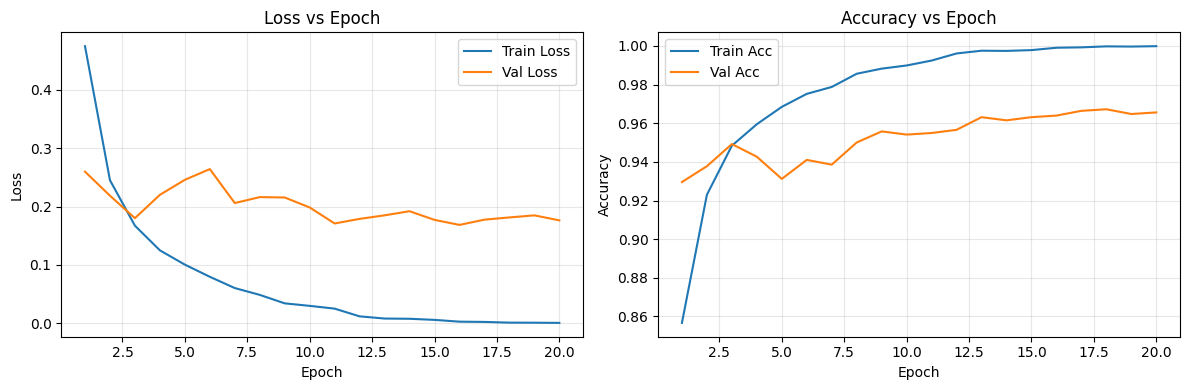

Best val_acc: 0.9672399672399672


In [5]:
# Plot training vs validation curves
epochs_range = list(range(1, cfg.epochs + 1))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Best val_acc:", max(history["val_acc"]))


Loading: best_efficientnetv2s_384.pth

Test results:
  loss=0.1880
  accuracy=0.9604
  weighted_recall=0.9604
  weighted_f1=0.9603

Confusion Matrix (rows=true, cols=predicted):
      batter biolog cardbo clothe  glass  metal  paper plasti  shoes  trash
batter     77      0      0      0      0      0      0      0      0      0
biolog      0     71      0      0      0      0      0      0      0      0
cardbo      0      0    137      0      0      0      3      1      0      1
clothe      0      0      0    189      0      0      0      1      0      0
 glass      0      1      0      0    168      2      1      3      0      0
 metal      2      0      0      1      1     86      0      2      0      1
 paper      1      0      5      0      0      2    124      0      1      2
plasti      0      0      0      0      8      2      0    148      0      3
 shoes      0      1      0      0      0      0      0      0    145      0
 trash      0      1      1      0      0      1     

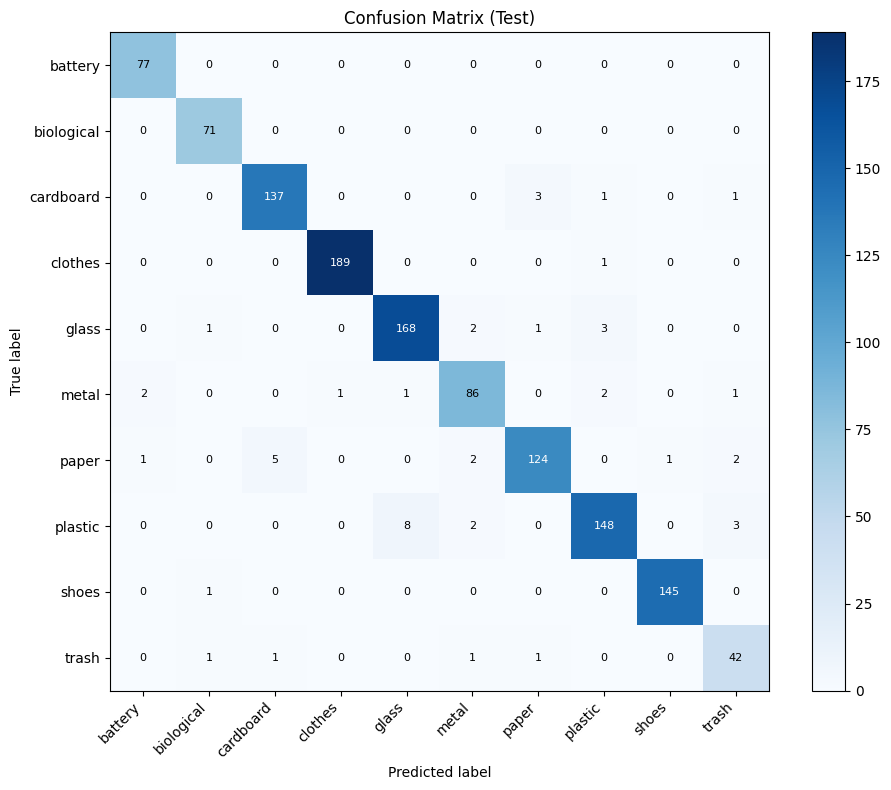

In [6]:
best_ckpt_path = "best_efficientnetv2s_384.pth"
print("Loading:", best_ckpt_path)

ckpt = torch.load(best_ckpt_path, map_location=device)

# Rebuild the same EfficientNetV2-S architecture
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

weights = EfficientNet_V2_S_Weights.DEFAULT
best_model = efficientnet_v2_s(weights=weights)

if isinstance(best_model.classifier, nn.Sequential) and isinstance(best_model.classifier[-1], nn.Linear):
    in_features = best_model.classifier[-1].in_features
    best_model.classifier[-1] = nn.Linear(in_features, num_classes)
else:
    raise RuntimeError("Unexpected EfficientNetV2-S classifier structure")

best_model.load_state_dict(ckpt["model_state_dict"], strict=True)
best_model = best_model.to(device)
best_model.eval()

class_names_ckpt = ckpt.get("class_names", class_names)

# Evaluate on test set + confusion matrix
cm_test = np.zeros((num_classes, num_classes), dtype=np.int64)
total_loss = 0.0
total_batches = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = best_model(inputs)
        loss = criterion(outputs, labels)
        total_loss += float(loss.item())
        total_batches += 1

        preds = outputs.argmax(dim=1)

        preds_cpu = preds.detach().cpu().numpy()
        labels_cpu = labels.detach().cpu().numpy()

        for t, p in zip(labels_cpu, preds_cpu):
            cm_test[t, p] += 1

avg_test_loss = total_loss / max(1, total_batches)
test_acc, test_w_recall, test_w_f1 = confusion_metrics_from_cm(cm_test)

print("\nTest results:")
print(f"  loss={avg_test_loss:.4f}")
print(f"  accuracy={test_acc:.4f}")
print(f"  weighted_recall={test_w_recall:.4f}")
print(f"  weighted_f1={test_w_f1:.4f}")

print("\nConfusion Matrix (rows=true, cols=predicted):")

# Print as labeled table (counts)
cell_width = 6
header = " " * cell_width + " ".join([name[:cell_width].rjust(cell_width) for name in class_names_ckpt])
print(header)
for i, true_name in enumerate(class_names_ckpt):
    row = [str(int(cm_test[i, j])).rjust(cell_width) for j in range(num_classes)]
    print(true_name[:cell_width].rjust(cell_width) + " " + " ".join(row))

# Plot heatmap
plt.figure(figsize=(10, 8))
im = plt.imshow(cm_test, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.colorbar(im)

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, [n for n in class_names_ckpt], rotation=45, ha="right")
plt.yticks(tick_marks, [n for n in class_names_ckpt])

# Annotate each cell with its count
thresh = cm_test.max() / 2.0
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            str(int(cm_test[i, j])),
            ha="center",
            va="center",
            color="white" if cm_test[i, j] > thresh else "black",
            fontsize=8,
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()
